# Tutorial 3: Random Generation → High-T Equilibration → Batch Quench

This tutorial demonstrates a **hybrid workflow** that combines random structure
generation with melt-quench sampling to produce multiple independent amorphous
TiO₂ structures:

1. **Generate** a random cubic TiO₂ structure (24 atoms, 3.2 g/cm³)
2. **Optimise** with CHGNet (fixed volume — preserves target density)
3. **Equilibrate** at 2000 K for 20 ps (NVT) — creates a well-sampled liquid
4. **Extract** 10 decorrelated snapshots from the high-T trajectory
5. **Batch quench** each snapshot independently (NVT): quench → low-T eq → final opt (Stages 5 → 6 → 7)

This approach is efficient because:
- Random placement + optimisation gives a reasonable starting liquid (skips slow heating)
- NVT ensemble preserves the target amorphous density throughout
- One long high-T equilibration is shared across all structures
- Each snapshot is quenched independently → statistically independent amorphous structures

**Estimated runtime:** ~15–20 min on CPU with CHGNet

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read, write
from ase.data import atomic_masses, atomic_numbers

---
## 3.1 Generate a random TiO₂ structure

We generate a single cubic TiO₂ cell with 24 atoms (8 Ti + 16 O)
at a target density of 3.5 g/cm³.

In [2]:
from amorphgen.pipeline.random_gen import generate_random

composition = {"Ti": 8, "O": 16}  # 24 atoms, TiO2 stoichiometry

atoms = generate_random(
    composition=composition,
    target_density=3.2,             # g/cm³ (amorphous TiO2 density)
    minsep={
        "Ti-Ti": 2.5,
        "Ti-O":  1.6,
        "O-O":   2.2,
    },
    seed=42,
    max_attempts_per_atom=50000,
)

print(f"Formula:  {atoms.get_chemical_formula()}")
print(f"Atoms:    {len(atoms)}")
print(f"Cell:     {atoms.cell[0,0]:.3f} x {atoms.cell[1,1]:.3f} x {atoms.cell[2,2]:.3f} Å")

total_mass = sum(atomic_masses[atomic_numbers[s]] for s in atoms.get_chemical_symbols())
vol_cm3 = atoms.get_volume() * 1e-24
density = (total_mass / 6.022e23) / vol_cm3
print(f"Density:  {density:.3f} g/cm³ (target: 3.2)")

write("TiO2_random.extxyz", atoms, format="extxyz")
print("\nSaved -> TiO2_random.extxyz")

Formula:  O16Ti8
Atoms:    24
Cell:     6.921 x 6.921 x 6.921 Å
Density:  3.200 g/cm³ (target: 3.2)

Saved -> TiO2_random.extxyz


---
## 3.2 Optimise the random structure

Relax the random structure to remove unphysical overlaps and
bring it to a local energy minimum. We optimise **atomic positions only**
(no cell relaxation) to preserve the target density of 3.2 g/cm³.

In [3]:
from amorphgen.utils import get_calculator
from ase.optimize import LBFGS
from ase.io import write

calc = get_calculator(model="chgnet", device="mps")
print("CHGNet calculator loaded.")

# Optimise positions only (no cell filter) to preserve target density
atoms.calc = calc
opt = LBFGS(atoms, logfile="TiO2_opt.log")
opt.run(fmax=0.1, steps=200)

e_per_atom = atoms.get_potential_energy() / len(atoms)
write("TiO2_optimised.extxyz", atoms, format="extxyz")
write("TiO2_optimised.cif", atoms)
print(f"\nOptimised energy: {e_per_atom:.4f} eV/atom")
print(f"Saved -> TiO2_optimised.extxyz, TiO2_optimised.cif")

optimised = atoms.copy()

[CHGNet] Loading pretrained model on mps
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on mps
CHGNet will run on mps
CHGNet calculator loaded.


/Users/c.kaewmeechai@bham.ac.uk/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/chgnet/model/model.py:898: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  volumes = torch.tensor(volumes, dtype=TORCH_DTYPE, device=atomic_numbers.device)



Optimised energy: -9.2314 eV/atom
Saved -> TiO2_optimised.extxyz, TiO2_optimised.cif


---
## 3.3 Equilibrate at 2000 K (NVT, 20 ps)

Run NVT MD at 2000 K to create a well-sampled disordered liquid.
NVT keeps the volume (and hence density) fixed at our target value.
The trajectory will be used to extract decorrelated snapshots.

In [4]:
from amorphgen.pipeline.equilibrate import run as eq_run

liquid = eq_run(
    optimised,
    cfg_override={
        "eq_high": {
            "ensemble": "NVT",
            "T": 2000,
            "steps": 10000,            # 20 ps at 2 fs timestep
            "timestep": 2.0,
            "friction": 0.01,
            "log_file": "TiO2_eq_2000K.log",
            "traj_file": "TiO2_eq_2000K.extxyz",
            "output_xyz": "TiO2_eq_2000K_final.extxyz",
        },
    },
    calc=calc,
    stage="high",
)

print(f"Equilibrated liquid: {len(liquid)} atoms")

[Stage 4] Using provided Atoms object
[Stage 4] NVT equilibration  T=2000 K  10000 steps (20.0 ps)
       0      0.0000    2077.5     -221.5539        6.4449     -215.1090      331.56
     100      0.2000    2170.6     -214.7446        6.7337     -208.0109      331.56
     200      0.4000    1748.3     -215.8460        5.4237     -210.4222      331.56
     300      0.6000    3013.1     -213.9150        9.3473     -204.5678      331.56
     400      0.8000    1758.6     -214.4727        5.4557     -209.0170      331.56
     500      1.0000    2045.6     -212.6271        6.3459     -206.2812      331.56
     600      1.2000    1889.5     -214.5396        5.8618     -208.6778      331.56
     700      1.4000    1993.0     -214.2121        6.1829     -208.0292      331.56
     800      1.6000    2205.2     -216.0163        6.8412     -209.1751      331.56
     900      1.8000    1728.1     -213.3410        5.3609     -207.9800      331.56
    1000      2.0000    1779.1     -212.6374       

---
## 3.4 Extract 10 snapshots from the trajectory

We select 10 evenly spaced frames from the high-T trajectory.
These are decorrelated liquid configurations that will be quenched
independently.

In [5]:
# Read the full trajectory
traj = read("TiO2_eq_2000K.extxyz", index=":")
print(f"Total frames in trajectory: {len(traj)}")

# Select 10 evenly spaced snapshots (skip first 10% for thermalisation)
n_snapshots = 10
start_frame = len(traj) // 10          # skip first 10%
indices = np.linspace(start_frame, len(traj) - 1, n_snapshots, dtype=int)

snapshots_dir = "snapshots"
os.makedirs(snapshots_dir, exist_ok=True)

snapshot_files = []
for i, idx in enumerate(indices):
    fname = f"{snapshots_dir}/snapshot_{i:04d}.extxyz"
    write(fname, traj[idx], format="extxyz")
    snapshot_files.append(fname)
    print(f"  Snapshot {i}: frame {idx} -> {fname}")

print(f"\n{n_snapshots} snapshots saved to {snapshots_dir}/")

Total frames in trajectory: 115
  Snapshot 0: frame 11 -> snapshots/snapshot_0000.extxyz
  Snapshot 1: frame 22 -> snapshots/snapshot_0001.extxyz
  Snapshot 2: frame 33 -> snapshots/snapshot_0002.extxyz
  Snapshot 3: frame 45 -> snapshots/snapshot_0003.extxyz
  Snapshot 4: frame 56 -> snapshots/snapshot_0004.extxyz
  Snapshot 5: frame 68 -> snapshots/snapshot_0005.extxyz
  Snapshot 6: frame 79 -> snapshots/snapshot_0006.extxyz
  Snapshot 7: frame 91 -> snapshots/snapshot_0007.extxyz
  Snapshot 8: frame 102 -> snapshots/snapshot_0008.extxyz
  Snapshot 9: frame 114 -> snapshots/snapshot_0009.extxyz

10 snapshots saved to snapshots/


---
## 3.5 Batch quench: Stages 5 → 6 → 7 on each snapshot

Each snapshot is independently:
- **Stage 5:** Quenched from 2000 → 300 K (NVT, ~2000 K/ps)
- **Stage 6:** Equilibrated at 300 K (NVT, 4 ps)
- **Stage 7:** Final optimisation

NVT preserves the cell volume throughout, maintaining our target density.
This produces 10 statistically independent amorphous TiO₂ structures.

In [6]:
from amorphgen import MeltQuenchPipeline

amorphous_structures = []

for i, snap_file in enumerate(snapshot_files):
    run_dir = f"batch_quench/run_{i:04d}"
    print(f"\n{'='*60}")
    print(f"  Run {i+1}/{n_snapshots}: {snap_file} -> {run_dir}")
    print(f"{'='*60}")

    pipe = MeltQuenchPipeline(
        input_file=snap_file,
        work_dir=run_dir,
        cfg_override={
            "model": "chgnet",
            "device": "cpu",

            "opt": {
                "fmax": 0.1,
                "max_steps": 100,
            },

            # Stage 5: quench (NVT, 2000 → 300 K, ~2000 K/ps)
            "quench": {
                "ensemble": "NVT",
                "T_start": 2000,
                "T_end": 300,
                "T_step": -200,
                "steps_per_T": 50,
                "timestep": 2.0,
                "friction": 0.01,
            },

            # Stage 6: low-T equilibration (NVT, 300 K, 4 ps)
            "eq_low": {
                "ensemble": "NVT",
                "T": 300,
                "steps": 2000,
                "timestep": 2.0,
                "friction": 0.01,
            },
        },
    )

    final = pipe.run(stages=[5, 6, 7])
    amorphous_structures.append(final.copy())

print(f"\n\nDone! {len(amorphous_structures)} amorphous structures generated.")


  Run 1/10: snapshots/snapshot_0000.extxyz -> batch_quench/run_0000
[CHGNet] Loading pretrained model on cpu
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on mps
CHGNet will run on cpu

═════════════════════════════════════════════════════════════════
  AmorphGen  v2.0  —  Melt-and-Quench Pipeline
  Model:  chgnet
  Input:  snapshots/snapshot_0000.extxyz
  Stages: [5, 6, 7]
  Output: batch_quench/run_0000/
═════════════════════════════════════════════════════════════════


─────────────────────────────────────────────────────────────────
  Stage 5: Quench (cooling ramp)
─────────────────────────────────────────────────────────────────

[Stage 4] Using provided Atoms object
[Stage 4] NVT quench: 2000 -> 300 K  (-200 K/step, 50 steps each)
  -> T =  2000 K
       0      0.0000    2035.9     -218.0945        6.3159     -211.7786      346.88
  -> T =  1800 K
     100      0.2000    1919.6     -217.0987        5.9551     -211.1437      346.88
  -> T =  1600 K
  -> T =  

---
## 3.6 Analyse the amorphous ensemble

### RDF across all 10 structures

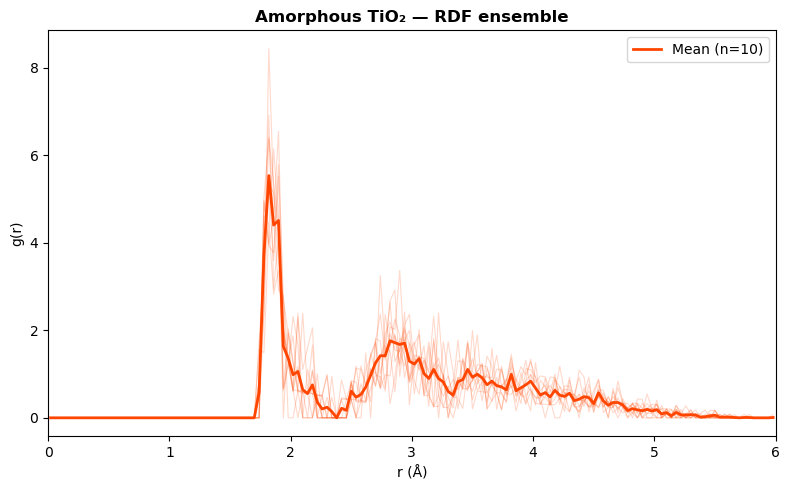

Saved -> rdf_ensemble_TiO2.png


In [7]:
def compute_rdf(atoms, rmax=6.0, nbins=150):
    """Compute the total radial distribution function."""
    d = atoms.get_all_distances(mic=True)
    np.fill_diagonal(d, np.inf)
    pairs = d[np.triu_indices_from(d, k=1)]
    pairs = pairs[pairs < rmax]
    hist, edges = np.histogram(pairs, bins=nbins, range=(0, rmax))
    r = 0.5 * (edges[:-1] + edges[1:])
    dr = edges[1] - edges[0]
    n = len(atoms)
    vol = atoms.get_volume()
    n_pairs = n * (n - 1) / 2
    shell_vol = 4 * np.pi * r**2 * dr
    g_r = hist * vol / (n_pairs * shell_vol)
    return r, g_r

fig, ax = plt.subplots(figsize=(8, 5))

for i, atoms in enumerate(amorphous_structures):
    r, g = compute_rdf(atoms)
    ax.plot(r, g, color="orangered", alpha=0.2, lw=0.8)

# Mean RDF
rdfs = [compute_rdf(a)[1] for a in amorphous_structures]
r = compute_rdf(amorphous_structures[0])[0]
mean_rdf = np.mean(rdfs, axis=0)
ax.plot(r, mean_rdf, color="orangered", lw=2, label=f"Mean (n={len(amorphous_structures)})")

ax.set_xlabel("r (Å)")
ax.set_ylabel("g(r)")
ax.set_title("Amorphous TiO₂ — RDF ensemble", fontweight="bold")
ax.set_xlim(0, 6)
ax.legend()
plt.tight_layout()
plt.savefig("rdf_ensemble_TiO2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> rdf_ensemble_TiO2.png")

### Density distribution

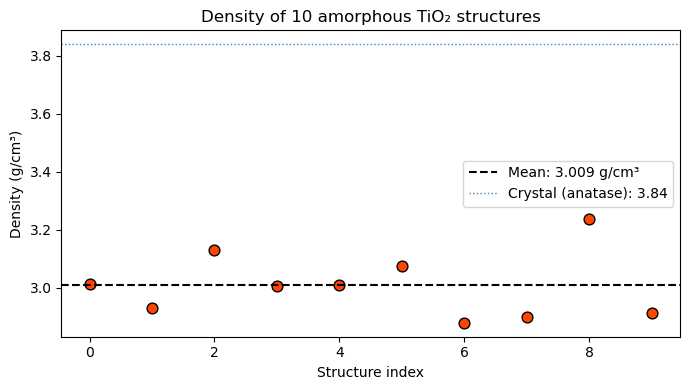

Mean density: 3.009 ± 0.107 g/cm³
Experimental amorphous TiO₂: ~3.4–3.6 g/cm³


In [8]:
def get_density(atoms):
    total_mass = sum(atomic_masses[atomic_numbers[s]] for s in atoms.get_chemical_symbols())
    vol_cm3 = atoms.get_volume() * 1e-24
    return (total_mass / 6.022e23) / vol_cm3

densities = [get_density(a) for a in amorphous_structures]

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(range(len(densities)), densities, color="orangered", edgecolor="black", s=60)
ax.axhline(np.mean(densities), color="black", ls="--", lw=1.5,
           label=f"Mean: {np.mean(densities):.3f} g/cm³")
ax.axhline(3.84, color="steelblue", ls=":", lw=1, label="Crystal (anatase): 3.84")
ax.set_xlabel("Structure index")
ax.set_ylabel("Density (g/cm³)")
ax.set_title("Density of 10 amorphous TiO₂ structures")
ax.legend()
plt.tight_layout()
plt.savefig("density_ensemble_TiO2.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean density: {np.mean(densities):.3f} ± {np.std(densities):.3f} g/cm³")
print(f"Experimental amorphous TiO₂: ~3.4–3.6 g/cm³")

### Coordination number (Ti–O)

In crystalline TiO₂ (rutile/anatase), Ti is 6-coordinated by O.
Amorphous TiO₂ typically shows a mix of 4-, 5-, and 6-fold coordination.

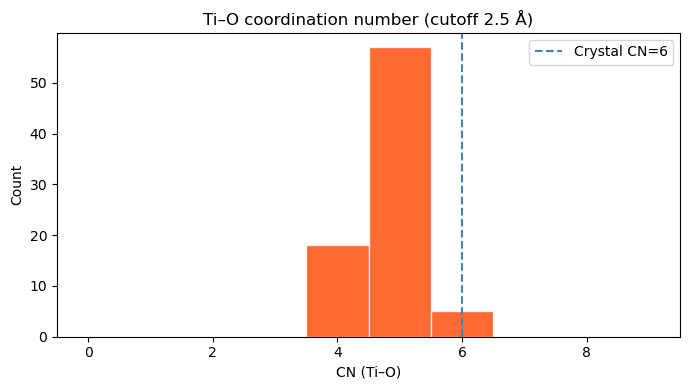

Mean CN: 4.84 ± 0.51
Crystal: CN = 6 (octahedral)


In [9]:
from ase.neighborlist import neighbor_list

def coordination_numbers(atoms, central, neighbour, cutoff):
    """Compute CN of 'central' atoms surrounded by 'neighbour' atoms."""
    i_arr, j_arr = neighbor_list('ij', atoms, cutoff)
    syms = np.array(atoms.get_chemical_symbols())
    central_idx = np.where(syms == central)[0]
    cn = np.zeros(len(central_idx), dtype=int)
    for k, ci in enumerate(central_idx):
        mask = (i_arr == ci) & (syms[j_arr] == neighbour)
        cn[k] = np.sum(mask)
    return cn

cutoff_TiO = 2.5  # Å — first coordination shell

cn_all = []
for atoms in amorphous_structures:
    cn = coordination_numbers(atoms, "Ti", "O", cutoff_TiO)
    cn_all.extend(cn)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(cn_all, bins=range(0, 10), align="left",
        color="orangered", edgecolor="white", alpha=0.8)
ax.axvline(6, ls="--", color="steelblue", label="Crystal CN=6")
ax.set_xlabel("CN (Ti–O)")
ax.set_ylabel("Count")
ax.set_title(f"Ti–O coordination number (cutoff {cutoff_TiO} Å)")
ax.legend()
ax.set_xlim(-0.5, 9.5)
plt.tight_layout()
plt.savefig("cn_ensemble_TiO2.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean CN: {np.mean(cn_all):.2f} ± {np.std(cn_all):.2f}")
print(f"Crystal: CN = 6 (octahedral)")

### Energy distribution

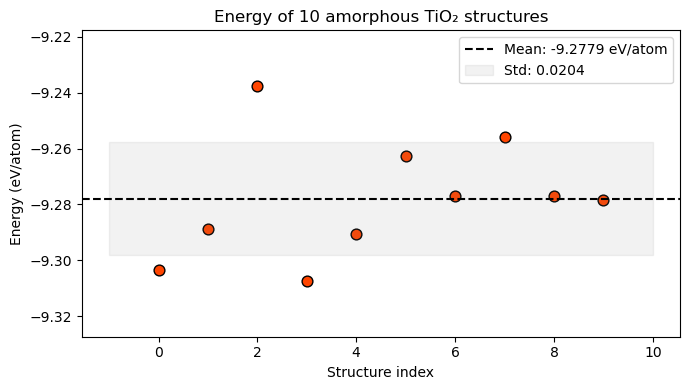

In [10]:
# Re-attach calculator to get energies
for a in amorphous_structures:
    a.calc = calc

energies = [a.get_potential_energy() / len(a) for a in amorphous_structures]
mean_e = np.mean(energies)
std_e = np.std(energies)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(range(len(energies)), energies, color="orangered", edgecolor="black", s=60)
ax.axhline(mean_e, color="black", ls="--", lw=1.5, label=f"Mean: {mean_e:.4f} eV/atom")
ax.fill_between([-1, len(energies)], mean_e - std_e, mean_e + std_e,
                color="gray", alpha=0.1, label=f"Std: {std_e:.4f}")
ax.set_ylim(np.min(energies) - 0.02, np.max(energies) + 0.02)
ax.set_xlabel("Structure index")
ax.set_ylabel("Energy (eV/atom)")
ax.set_title("Energy of 10 amorphous TiO₂ structures")
ax.legend()
plt.tight_layout()
plt.savefig("energy_ensemble_TiO2.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Note: CLI equivalent

This workflow can also be done from the command line:

```bash
# Step 1: Generate random structure
amorphgen --random-gen \
    --composition Ti=8,O=16 \
    --target-density 3.2 \
    --n-structures 1 \
    --model chgnet \
    --device cpu \
    --work-dir random_TiO2

# Step 2-4: Run stages 1-4 (optimise + premelt + melt + high-T eq)
amorphgen random_TiO2/TiO2_000.extxyz \
    --model chgnet \
    --device cpu \
    --stages 1 4 \
    --eq-high-ensemble NVT \
    --eq-high-T 2000 \
    --eq-high-steps 10000 \
    --work-dir melt_run

# Step 5: Batch quench from snapshots (NVT)
amorphgen --batch-quench \
    --snapshot-dir snapshots/ \
    --n-runs 10 --select uniform \
    --batch-stages 5 6 7 \
    --quench-ensemble NVT \
    --eq-low-ensemble NVT \
    --model chgnet \
    --device cpu \
    --work-dir batch_quench
```

In [11]:
print(f"{'Property':<25s}  {'Mean':>10s}  {'Std':>10s}  {'Crystal':>10s}")
print("-" * 60)
print(f"{'Density (g/cm³)':<25s}  {np.mean(densities):10.3f}  {np.std(densities):10.3f}  {'3.84':>10s}")
print(f"{'Energy (eV/atom)':<25s}  {mean_e:10.4f}  {std_e:10.4f}  {'—':>10s}")
print(f"{'Ti–O CN':<25s}  {np.mean(cn_all):10.2f}  {np.std(cn_all):10.2f}  {'6.0':>10s}")
print(f"\n10 independent amorphous TiO₂ structures generated.")
print(f"Structures saved in batch_quench/run_NNNN/ directories.")

Property                         Mean         Std     Crystal
------------------------------------------------------------
Density (g/cm³)                 3.009       0.107        3.84
Energy (eV/atom)              -9.2779      0.0204           —
Ti–O CN                          4.84        0.51         6.0

10 independent amorphous TiO₂ structures generated.
Structures saved in batch_quench/run_NNNN/ directories.


---
## Note: CLI equivalent

This workflow can also be done from the command line:

```bash
# Step 1: Generate random structure
amorphgen --random-gen \
    --composition Ti=8,O=16 \
    --target-density 3.5 \
    --n-structures 1 \
    --model chgnet \
    --device cpu \
    --work-dir random_TiO2

# Step 2-4: Run stages 1-4 (optimise + premelt + melt + high-T eq)
amorphgen random_TiO2/TiO2_000.extxyz \
    --model chgnet \
    --device cpu \
    --stages 1 4 \
    --eq-high-ensemble NPT \
    --eq-high-T 2000 \
    --eq-high-steps 10000 \
    --work-dir melt_run

# Step 5: Batch quench from snapshots
amorphgen --batch-quench \
    --snapshot-dir snapshots/ \
    --n-runs 10 --select uniform \
    --batch-stages 5 6 7 \
    --model chgnet \
    --device cpu \
    --work-dir batch_quench
```

---
## Output summary

After running this tutorial, you should have:

```
TiO2_random.extxyz              # random starting structure
TiO2_optimised.cif              # optimised structure
TiO2_eq_2000K.extxyz            # high-T equilibration trajectory
TiO2_eq_2000K_final.extxyz      # final liquid snapshot
snapshots/
├── snapshot_0000.extxyz        # 10 decorrelated liquid snapshots
├── snapshot_0001.extxyz
├── ...
└── snapshot_0009.extxyz
batch_quench/
├── run_0000/                   # 10 independent quench runs
│   ├── stage5_quench.extxyz
│   ├── stage6_eq.extxyz
│   └── opt_final.cif           # amorphous structure
├── run_0001/
├── ...
└── run_0009/
rdf_ensemble_TiO2.png
density_ensemble_TiO2.png
cn_ensemble_TiO2.png
energy_ensemble_TiO2.png
```

Open any `opt_final.cif` in VESTA to visualise the amorphous structures.